## Isolation Forest Anomaly Detection

In [1]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import IsolationForest

In [3]:
# Step 2: Load dataset
df = pd.read_csv('healthcare.csv')
df.head()


,0,1
0,1.616671,1.944522
1,1.256461,1.609444
2,-2.343919,4.392961
3,1.195393,2.794485
4,-3.329586,5.303160


In [4]:
df.shape

(250, 2)

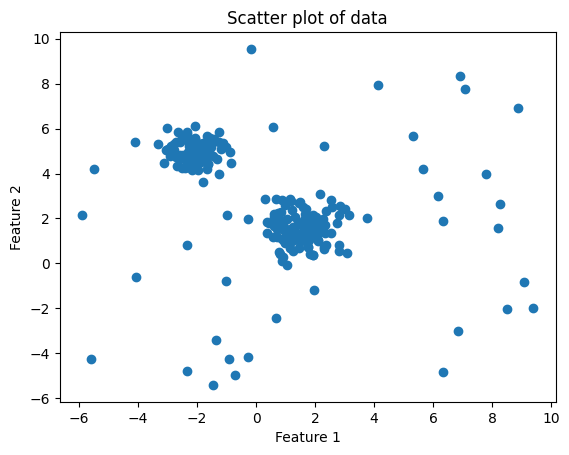

In [5]:
# Step 3: Visualize the data
# Scatter plot of the first two columns
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.title("Scatter plot of data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [6]:
# Step 4: Create and train Isolation Forest
# contamination=0.2 means we expect ~20% of points to be anomalies
clf = IsolationForest(contamination='auto')
clf.fit(df)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,None
,verbose,0
,warm_start,False


In [7]:
# Step 5: Make predictions
# Prediction output: 1 = normal, -1 = anomaly
predictions = clf.predict(df)
print(predictions)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
 -1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1
 -1  1 -1  1  1  1 -1  1  1  1  1 -1  1 -1  1 -1  1  1  1  1 -1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1
  1 -1  1  1 -1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1  1 -1 -1  1]


In [8]:
len(predictions)

250

In [9]:
# Step 6: Find the indices of anomalies
anomaly_index = np.where(predictions == -1)  # Get indices where prediction is -1 (anomaly)
print(anomaly_index)

(array([ 20,  24,  45,  48,  53,  55,  63,  72,  74,  78,  83,  85,  87,
        92,  97, 108, 114, 119, 130, 133, 141, 151, 160, 167, 179, 187,
       199, 212, 217, 220, 221, 227, 242, 247, 248]),)


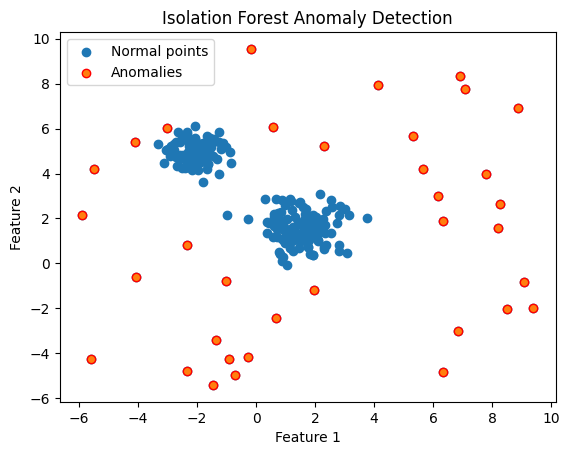

In [10]:
# Step 7: Visualize anomalies on the scatter plot
x = df.values  # Convert dataframe to NumPy array for indexing
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], label="Normal points")
plt.scatter(x[anomaly_index, 0], x[anomaly_index, 1], edgecolors="r", label="Anomalies")  # Red points
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()